# Telco Customer Churn — Combined Classical ML Project

A complete classical machine learning pipeline applied to a single real-world dataset (Telco Customer Churn), covering:

- **Data Preprocessing** — cleaning, encoding, handling hidden missing values
- **Exploratory Data Analysis** — visualizing distributions and churn patterns
- **Unsupervised Learning** — PCA + K-Means to discover natural customer segments
- **Classification** — predicting customer churn (Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost)
- **Regression** — predicting Monthly Charges (Linear, Ridge, Lasso, Elastic Net)
- **Final Demo** — takes custom user input, predicts Monthly Charges, then uses that to predict Churn

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [9]:
#loading the data
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
#checking the structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
#total charges is object datatype. converting it into numerical and checking missing items
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [15]:
# See the actual problematic rows
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [18]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [22]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [23]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
for i in df.select_dtypes(include = "object").columns:
  print(df[i].value_counts())
  print("***"*10)

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
******************************
gender
Male      3555
Female    3488
Name: count, dtype: int64
******************************
Partner
No     3641
Yes    3402
Name: count, dtype: int64
******************************
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
******************************
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
******************************
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
******************************
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
******************************
OnlineSecurity
No                     3498
Yes                    2019
No internet service    

In [26]:
#dropping the useless columns
df.drop(columns = ['customerID'], inplace = True)

In [27]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869


In [28]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [30]:
#categorizing every column

#group 1 with simple binary, grop2 2 with yes/no and others like no phone service, no internet service and so on
#group 3 with true multi category nominal like internet service : dsl, fiber optic or none
# we simplify group2 because no internet access and no usully gives same meaning.

cols_to_simplify = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_simplify:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [31]:
# appliying the encoding

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'] + cols_to_simplify
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


# Multi-category nominal — One-Hot Encoding
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [33]:
df.shape

(7043, 24)

In [34]:
df.dtypes.value_counts()


,count
int64,15
bool,7
float64,2


In [35]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape, y.shape)

(7043, 23) (7043,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # stratify = y helps to keep class distribution of y approx same in train and test datasets

print(X_train.shape, X_test.shape)

(5634, 23) (1409, 23)


In [37]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

,proportion
Churn,
0,0.734564
1,0.265436


In [38]:
# These are the only truly continuous numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# keeping non scaled version of datasets for tree based models
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,0,0,1,...,0,-0.521976,-0.262257,False,False,False,False,False,True,False
3151,1,0,1,1,-0.711743,1,0,1,0,0,...,0,0.337478,-0.503635,True,False,False,False,False,False,True
4860,1,0,1,1,-0.793155,0,0,1,1,0,...,0,-0.809013,-0.749883,False,False,False,True,False,False,True
3867,0,0,1,0,-0.263980,1,0,0,1,1,...,1,0.284384,-0.172722,False,False,False,True,True,False,False
3810,1,0,1,1,-1.281624,1,0,0,0,0,...,0,-0.676279,-0.989374,False,False,False,False,False,True,False


EDA

In [39]:
# reloading the data again for eda
df_eda = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_eda = df_eda.drop('customerID', axis=1)
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'] = df_eda['TotalCharges'].fillna(0)


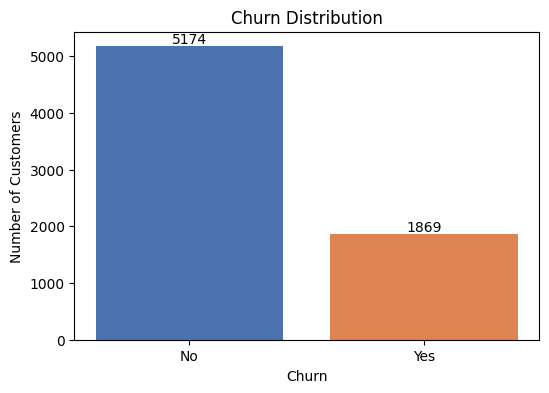

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [40]:
import matplotlib.pyplot as plt

churn_counts = df_eda['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values, color=['#4C72B0', '#DD8452'])
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Churn Distribution')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

print(df_eda['Churn'].value_counts(normalize=True) * 100)

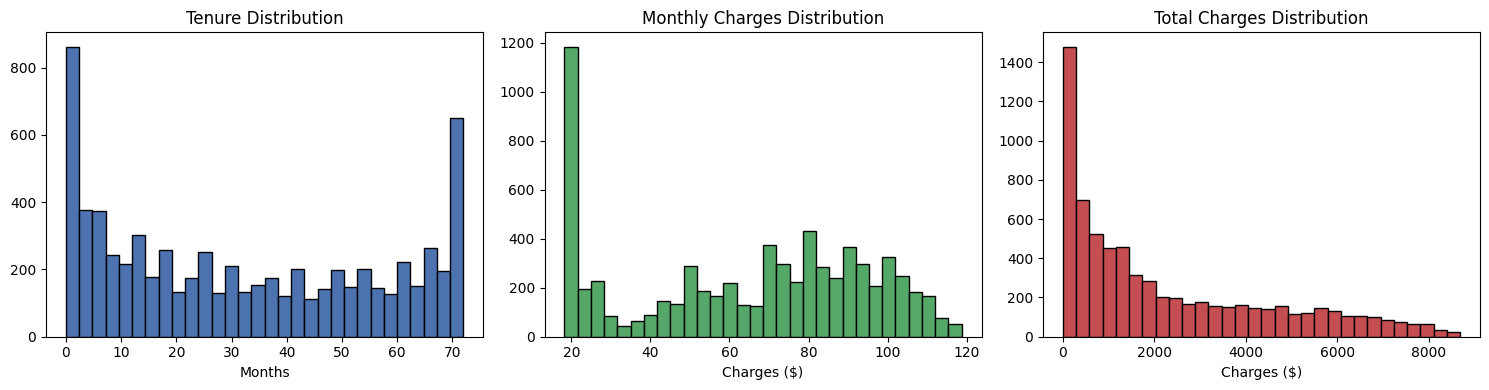

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_eda['tenure'], bins=30, color='#4C72B0', edgecolor='black')
axes[0].set_title('Tenure Distribution')
axes[0].set_xlabel('Months')

axes[1].hist(df_eda['MonthlyCharges'], bins=30, color='#55A868', edgecolor='black')
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_xlabel('Charges ($)')

axes[2].hist(df_eda['TotalCharges'], bins=30, color='#C44E52', edgecolor='black')
axes[2].set_title('Total Charges Distribution')
axes[2].set_xlabel('Charges ($)')

plt.tight_layout()
plt.show()

In [43]:
print(X_train_scaled.shape, X_test_scaled.shape)   # for Logistic Regression, KNN, SVM
print(X_train.shape, X_test.shape)           # for Decision Tree, Random Forest, XGBoost
print(y_train.shape, y_test.shape)

(5634, 23) (1409, 23)
(5634, 23) (1409, 23)
(5634,) (1409,)


Running the classification models

In [44]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\n", classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Accuracy: 0.8055358410220014
Precision: 0.6582278481012658
Recall: 0.5561497326203209
F1: 0.6028985507246377

Confusion Matrix:
 [[927 108]
 [166 208]]

               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [45]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=== KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== KNN ===
Accuracy: 0.7629524485450674
Precision: 0.553763440860215
Recall: 0.5508021390374331
F1: 0.5522788203753352

Confusion Matrix:
 [[869 166]
 [168 206]]


In [46]:
#svm

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

=== SVM ===
Accuracy: 0.794889992902768
Precision: 0.6534296028880866
Recall: 0.4839572192513369
F1: 0.5560675883256528

Confusion Matrix:
 [[939  96]
 [193 181]]


In [47]:
#descision tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)   # unscaled data — trees don't need scaling

y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 0.801277501774308
Precision: 0.6678571428571428
Recall: 0.5
F1: 0.5718654434250765

Confusion Matrix:
 [[942  93]
 [187 187]]


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8034066713981547
Precision: 0.6763636363636364
Recall: 0.49732620320855614
F1: 0.5731895223420647

Confusion Matrix:
 [[946  89]
 [188 186]]


In [49]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                            eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy: 0.7977288857345636
Precision: 0.6478405315614618
Recall: 0.5213903743315508
F1: 0.5777777777777777

Confusion Matrix:
 [[929 106]
 [179 195]]


tuining only logistic regression and xgboost based on precision, recall and f1 score

In [50]:
#tuining logistic regression
from sklearn.model_selection import GridSearchCV

param_grid_log = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_log = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                          param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_scaled, y_train)

print("Best params:", grid_log.best_params_)
print("Best CV F1:", grid_log.best_score_)

# Evaluate tuned model on test set
best_log = grid_log.best_estimator_
y_pred_log_tuned = best_log.predict(X_test_scaled)

print("\n=== Tuned Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log_tuned))
print("Precision:", precision_score(y_test, y_pred_log_tuned))
print("Recall:", recall_score(y_test, y_pred_log_tuned))
print("F1:", f1_score(y_test, y_pred_log_tuned))

Best params: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.599371387712228

=== Tuned Logistic Regression ===
Accuracy: 0.8019872249822569
Precision: 0.6498422712933754
Recall: 0.5508021390374331
F1: 0.5962373371924746


In [51]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist_xgb = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(2, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=30, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
random_xgb.fit(X_train, y_train)

print("Best params:", random_xgb.best_params_)
print("Best CV F1:", random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("\n=== Tuned XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("F1:", f1_score(y_test, y_pred_xgb_tuned))

Best params: {'colsample_bytree': np.float64(0.9332779646944658), 'learning_rate': np.float64(0.062009396052331626), 'max_depth': 2, 'n_estimators': 213, 'subsample': np.float64(0.672894435115225)}
Best CV F1: 0.5936510308061622

=== Tuned XGBoost ===
Accuracy: 0.8005677785663591
Precision: 0.6576271186440678
Recall: 0.5187165775401069
F1: 0.5799701046337817


UNSUPERVISED LEARNING

In [52]:
# Combine train+test scaled data for clustering (unsupervised — no leakage risk)
import pandas as pd

X_full_scaled = pd.concat([X_train_scaled, X_test_scaled], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

print(X_full_scaled.shape)

(7043, 23)


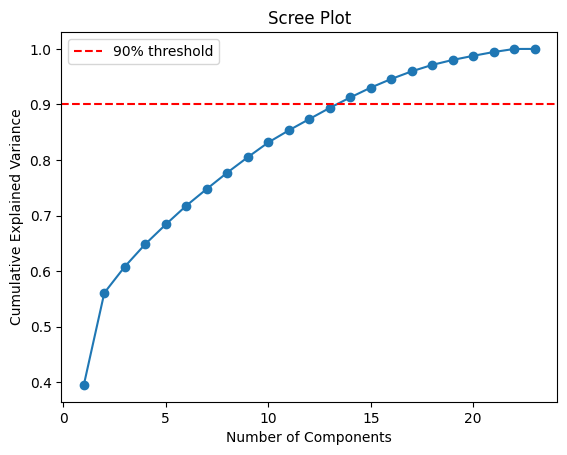

[0.39512015 0.5608312  0.60812172 0.64865867 0.68406638 0.71779138
 0.747952   0.77736348 0.8050889  0.8316281  0.85336539 0.87369479
 0.89387585 0.91266945 0.93035525 0.94592171 0.95967361 0.97124641
 0.98018783 0.98760033 0.99444179 0.99994868 1.        ]


In [53]:
#pca
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_full_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) #cumulative sum for variance

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.show()

print(cumulative_variance)

In [54]:
pca = PCA(n_components=2) # we took 2 to actually see the number of data on the screen, and not preserve information as we got from the above graph that we needed 10-15 components to actually preserve the information
X_pca = pca.fit_transform(X_full_scaled)

print("Variance captured by 2 components:", sum(pca.explained_variance_ratio_))

Variance captured by 2 components: 0.5608312049694832


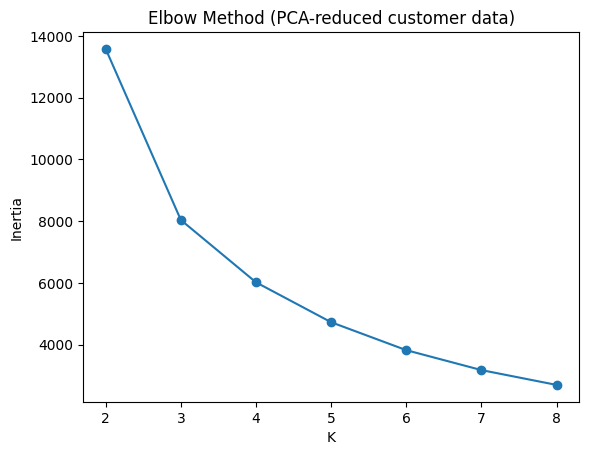

In [55]:
#finding the best k
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method (PCA-reduced customer data)')
plt.show()

In [56]:
from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"K={k} → Silhouette Score: {score:.3f}")

K=2 → Silhouette Score: 0.453
K=3 → Silhouette Score: 0.446
K=4 → Silhouette Score: 0.442
K=5 → Silhouette Score: 0.406
K=6 → Silhouette Score: 0.416
K=7 → Silhouette Score: 0.412
K=8 → Silhouette Score: 0.416


In [58]:
# we take k = 2
model_kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
cluster_labels = model_kmeans.fit_predict(X_pca)

print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts())

Cluster sizes:
1    4523
0    2520
Name: count, dtype: int64


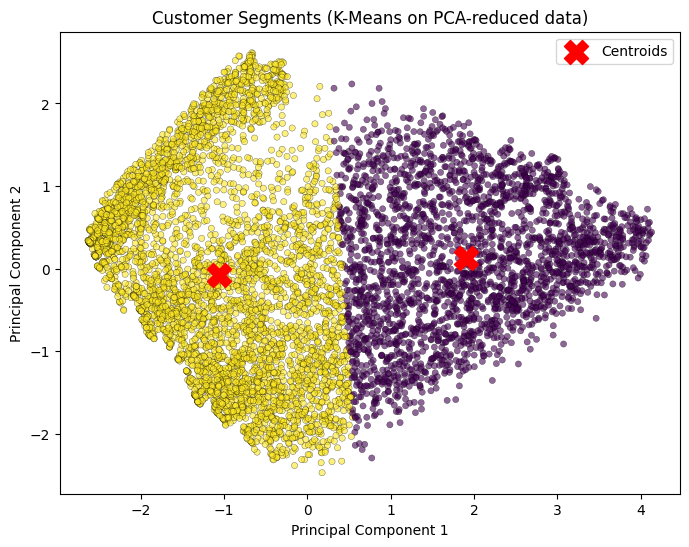

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=20, alpha=0.6, edgecolor='k', linewidth=0.3)

centroids = model_kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=300, label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments (K-Means on PCA-reduced data)')
plt.legend()
plt.show()

In [60]:
cluster_df = pd.DataFrame({
    'cluster': cluster_labels,
    'churn': y_full.values
})

churn_rate_by_cluster = cluster_df.groupby('cluster')['churn'].mean()
print("Churn rate by cluster:")
print(churn_rate_by_cluster)

cluster_sizes = cluster_df['cluster'].value_counts()
print("\nCluster sizes:")
print(cluster_sizes)

Churn rate by cluster:
cluster
0    0.182937
1    0.311298
Name: churn, dtype: float64

Cluster sizes:
cluster
1    4523
0    2520
Name: count, dtype: int64


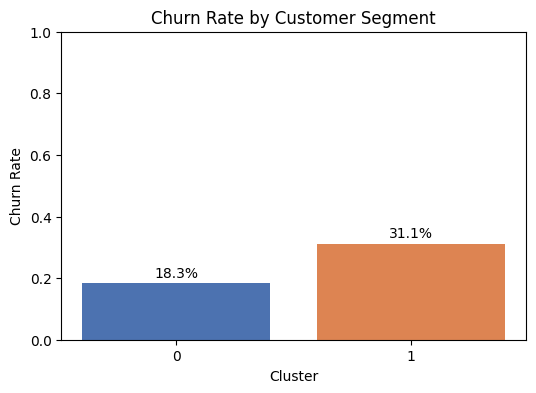

In [61]:
plt.figure(figsize=(6,4))
plt.bar(churn_rate_by_cluster.index.astype(str), churn_rate_by_cluster.values, color=['#4C72B0', '#DD8452'])
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Customer Segment')
plt.ylim(0, 1)
for i, v in enumerate(churn_rate_by_cluster.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')
plt.show()

regression

In [62]:
#monthly charges becomes label now.

# Drop BOTH TotalCharges (leakage) AND Churn from features
X_reg = df.drop(['MonthlyCharges', 'TotalCharges', 'Churn'], axis=1)
y_reg = df['MonthlyCharges']

print(X_reg.shape, y_reg.shape)

(7043, 21) (7043,)


In [63]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(X_train_reg.shape, X_test_reg.shape)

(5634, 21) (1409, 21)


In [65]:
from sklearn.preprocessing import StandardScaler

numeric_cols_reg = ['tenure']

scaler_reg = StandardScaler()

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[numeric_cols_reg] = scaler_reg.fit_transform(X_train_reg[numeric_cols_reg])
X_test_reg_scaled[numeric_cols_reg] = scaler_reg.transform(X_test_reg[numeric_cols_reg])

In [66]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_lin = lin_model.predict(X_test_reg_scaled)

print("=== Linear Regression ===")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)))
print("R2:", r2_score(y_test_reg, y_pred_lin))

=== Linear Regression ===
MAE: 0.7892749564822731
RMSE: 1.0512898797235315
R2: 0.998779278341754


In [67]:
#ridge, lasso, and elastic net

from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-3, 2, 30)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge_cv.predict(X_test_reg_scaled)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_reg_scaled, y_train_reg)
y_pred_lasso = lasso_cv.predict(X_test_reg_scaled)

elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=[0.2, 0.5, 0.8], cv=5, max_iter=10000)
elastic_cv.fit(X_train_reg_scaled, y_train_reg)
y_pred_elastic = elastic_cv.predict(X_test_reg_scaled)

for name, y_pred, model in [('Ridge', y_pred_ridge, ridge_cv),
                              ('Lasso', y_pred_lasso, lasso_cv),
                              ('ElasticNet', y_pred_elastic, elastic_cv)]:
    print(f"=== {name} (alpha={model.alpha_:.4f}) ===")
    print("MAE:", mean_absolute_error(y_test_reg, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred)))
    print("R2:", r2_score(y_test_reg, y_pred))
    print()

=== Ridge (alpha=0.0530) ===
MAE: 0.7892963728042209
RMSE: 1.0513318173370345
R2: 0.998779180946782

=== Lasso (alpha=0.0049) ===
MAE: 0.7890952598692863
RMSE: 1.0510768585839496
R2: 0.9987797729972777

=== ElasticNet (alpha=0.0010) ===
MAE: 0.7897640194853459
RMSE: 1.0519972810162448
R2: 0.998777634968924



In [69]:
coef_df = pd.DataFrame({
    'feature': X_reg.columns,
    'coefficient': lin_model.coef_
}).sort_values('coefficient', ascending=False)

print(coef_df)

                                  feature  coefficient
14            InternetService_Fiber optic    24.948151
5                            PhoneService    20.034640
11                            StreamingTV     9.986906
12                        StreamingMovies     9.951051
7                          OnlineSecurity     5.055063
10                            TechSupport     5.039899
6                           MultipleLines     5.018460
9                        DeviceProtection     5.018438
8                            OnlineBackup     4.986724
0                                  gender     0.017038
1                           SeniorCitizen     0.012433
18  PaymentMethod_Credit card (automatic)     0.012426
2                                 Partner     0.010263
20             PaymentMethod_Mailed check     0.005339
19         PaymentMethod_Electronic check    -0.000716
4                                  tenure    -0.005287
13                       PaperlessBilling    -0.017123
3         

In [70]:
"""
In the above condition, all models are giving similar performance.
Regularization mainly hepls when there is overfitting risk. but here, there is no overfitting risk or unstable weights.
relationship is generally clean and linear. so, reguklarization has nothing meaningful to fix
"""

'\nIn the above condition, all models are giving similar performance. \nRegularization mainly hepls when there is overfitting risk. but here, there is no overfitting risk or unstable weights. \nrelationship is generally clean and linear. so, reguklarization has nothing meaningful to fix\n'

In [73]:
#using linear regression

from sklearn.model_selection import cross_val_predict

predicted_monthly_train = cross_val_predict(LinearRegression(), X_train_reg_scaled, y_train_reg, cv=5)

predicted_monthly_test = lin_model.predict(X_test_reg_scaled)

print(predicted_monthly_train[:5])
print(predicted_monthly_test[:5])

[64.90554953 99.88783094 24.96016151 69.9582194  65.04761913]
[24.95966268 24.98735779 19.92427981 74.96775079 50.00388654]


simple user imput which will predict monthly charges and churn

In [74]:

binary_map = {'No': 0, 'Yes': 1}
gender_map = {'Female': 0, 'Male': 1}
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def predict_customer(raw_input):
    new_customer = pd.DataFrame([raw_input])

    for col in service_cols:
        new_customer[col] = new_customer[col].replace(
            {'No internet service': 'No', 'No phone service': 'No'}
        )

    for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'] + service_cols:
        new_customer[col] = new_customer[col].map(binary_map)
    new_customer['gender'] = new_customer['gender'].map(gender_map)

    # One-Hot Encode nominal columns
    new_customer = pd.get_dummies(new_customer, columns=['InternetService', 'Contract', 'PaymentMethod'])

  # Predict Monthly Charges
    new_customer_reg = new_customer.reindex(columns=X_train_reg.columns, fill_value=0)
    new_customer_reg[['tenure']] = scaler_reg.transform(new_customer_reg[['tenure']])
    predicted_monthly = lin_model.predict(new_customer_reg)[0]
    print(f"Predicted Monthly Charges: ${predicted_monthly:.2f}")

    #  Predict Churn using predicted Monthly Charges
    new_customer_clf = new_customer.reindex(columns=X_train.columns, fill_value=0)
    new_customer_clf['MonthlyCharges'] = predicted_monthly
    new_customer_clf['TotalCharges'] = predicted_monthly * raw_input['tenure']

    new_customer_clf_scaled = new_customer_clf.copy()
    new_customer_clf_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        new_customer_clf[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )

    churn_pred = log_model.predict(new_customer_clf_scaled)[0]
    churn_prob = log_model.predict_proba(new_customer_clf_scaled)[0][1]

    print(f"Predicted Churn: {'Yes' if churn_pred == 1 else 'No'}")
    print(f"Churn Probability: {churn_prob:.2%}")

    return predicted_monthly, churn_pred, churn_prob

In [75]:
sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check'
}

predict_customer(sample_customer)

Predicted Monthly Charges: $89.88
Predicted Churn: Yes
Churn Probability: 77.03%


(np.float64(89.87954477590154), np.int64(1), np.float64(0.7702818236493906))